# Self-Consistency and Multiple Paths of Reasoning Tutorial

## Overview

This tutorial explores the concept of self-consistency and multiple paths of reasoning in prompt engineering. We'll focus on techniques for generating diverse reasoning paths and aggregating results to improve the quality and reliability of AI-generated answers.

## Motivation

Large language models can sometimes produce inconsistent or unreliable outputs. By leveraging multiple reasoning paths and aggregating results, we can enhance the robustness and accuracy of AI-generated responses. This approach is particularly useful for complex problem-solving tasks where a single path of reasoning might be insufficient or prone to errors.

## Key Components

1. Generating multiple reasoning paths
2. Aggregating results for better answers
3. Implementing self-consistency checks
4. Applying these techniques to various problem-solving scenarios

## Method Details

Our approach involves the following steps:

1. Setting up the environment with necessary libraries (OpenAI and LangChain)
2. Designing prompts that encourage diverse reasoning paths
3. Generating multiple responses using these prompts
4. Implementing aggregation methods to combine and analyze the generated responses
5. Applying self-consistency checks to evaluate the reliability of the results
6. Demonstrating the effectiveness of this approach on various problem types

Throughout the tutorial, we'll use practical examples to illustrate how these techniques can be applied to enhance the quality and reliability of AI-generated answers.

By the end of this tutorial, you'll have a solid understanding of how to implement self-consistency and multiple paths of reasoning in your prompt engineering workflows, leading to more robust and reliable AI-generated responses.

## Conclusion

This tutorial will equipped you with powerful techniques for enhancing the reliability and consistency of AI-generated responses through self-consistency and multiple paths of reasoning. By implementing these methods, you can:

1. Generate diverse problem-solving approaches, reducing the risk of biased or narrow solutions.
2. Aggregate multiple reasoning paths to arrive at more robust and reliable answers.
3. Apply self-consistency checks to evaluate and improve the quality of AI-generated outputs.
4. Adapt these techniques to various problem types, from factual queries to complex reasoning tasks.

Mastering these skills will significantly improve your ability to leverage AI language models for more accurate and trustworthy results across a wide range of applications. As you continue to explore and refine these techniques, you'll be better equipped to handle complex problems and generate high-quality, consistent outputs in your AI-driven projects.

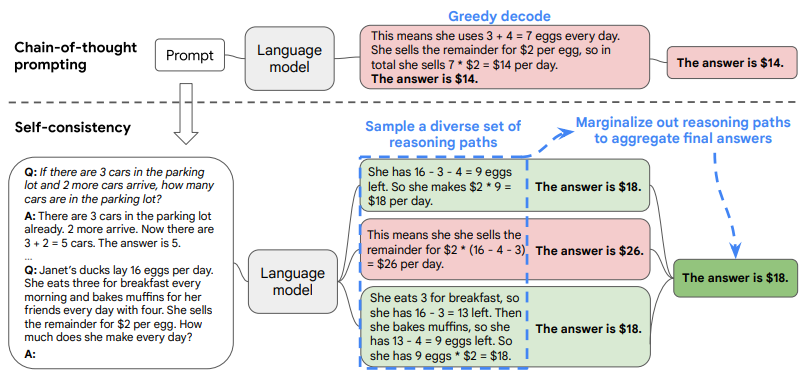

## Setup

First, let's import the necessary libraries and set up our environment.

In [ ]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv
from collections import Counter

# Load environment variables
load_dotenv(os.path.join("..", ".env"), override=True)

# Initialize the language model
llm = ChatOpenAI(model="gpt-4o-mini")

## Generating Multiple Reasoning Paths

Let's create a function that generates multiple reasoning paths for a given problem.

In [11]:
def generate_multiple_paths(problem, num_paths=3):
    """
    Generate multiple reasoning paths for a given problem.
    
    Args:
    problem (str): The problem statement.
    num_paths (int): Number of reasoning paths to generate.
    
    Returns:
    list: A list of generated reasoning paths.
    """
    prompt_template = PromptTemplate(
        input_variables=["problem", "path_number"],
        template="""Solve the following problem using a unique approach. This is reasoning path {path_number}.
        Problem: {problem}
        Reasoning path {path_number}:"""
    )

    paths = []
    for i in range(num_paths):
        chain = prompt_template | llm
        response = chain.invoke({"problem": problem, "path_number": i+1}).content
        paths.append(response)
    
    return paths

Now, let's test our function with a sample problem.

In [12]:
problem = "A ball is thrown upwards with an initial velocity of 20 m/s. How high will it go?"
paths = generate_multiple_paths(problem)

for i, path in enumerate(paths, 1):
    print(f"Path {i}:\n{path}\n")

Path 1:
To determine how high the ball will rise when thrown upwards with an initial velocity of 20 m/s, we can employ kinematic equations for vertical motion under constant acceleration due to gravity.

### Given:
- Initial velocity, \( v_0 = 20 \, \text{m/s} \) (upward)
- Final velocity at the highest point, \( v = 0 \, \text{m/s} \) (at the peak, the ball momentarily stops)
- Acceleration due to gravity, \( g = -9.81 \, \text{m/s}^2 \) (negative because it is acting downwards)

### Kinematic Equation:
We can use the kinematic equation that relates the initial velocity, final velocity, acceleration, and displacement:

\[
v^2 = v_0^2 + 2a s
\]

Where:
- \( s \) is the maximum height we want to find.
- Rearranging gives us:

\[
s = \frac{v^2 - v_0^2}{2a}
\]

### Plugging in the values:
Since we are looking for the maximum height, we will plug in the defined values:

- \( v = 0 \, \text{m/s} \)
- \( v_0 = 20 \, \text{m/s} \)
- \( a = -9.81 \, \text{m/s}^2 \)

\[
s = \frac{0^2 - (20)^2}{

## Aggregating Results

Now that we have multiple reasoning paths, let's create a function to aggregate the results and determine the most consistent answer.

In [13]:
def aggregate_results(paths):
    """
    Aggregate results from multiple reasoning paths.
    
    Args:
    paths (list): List of reasoning paths.
    
    Returns:
    str: The most consistent answer.
    """
    prompt_template = PromptTemplate(
        input_variables=["paths"],
        template="""Analyze the following reasoning paths and determine the most consistent answer. If there are discrepancies, explain why and provide the most likely correct answer.
        Reasoning paths:
        {paths}
        
        Most consistent answer:"""
    )

    chain = prompt_template | llm
    response = chain.invoke({"paths": "\n".join(paths)}).content
    return response

Let's apply this aggregation function to our previous results.

In [14]:
aggregated_result = aggregate_results(paths)
print("Aggregated Result:\n", aggregated_result)

Aggregated Result:
 To determine the most consistent answer for the maximum height a ball will rise when thrown upwards with an initial velocity of 20 m/s, we have analyzed the reasoning paths using both kinematic equations and energy conservation principles. 

### Kinematic Approach:
1. **Using Kinematic Equation:**
   - The kinematic equation derived was:
     \[
     s = \frac{v^2 - v_0^2}{2a}
     \]
   - Substituting in the values:
     \[
     s = \frac{0 - (20)^2}{2 \times (-9.81)} = \frac{-400}{-19.62} \approx 20.39 \, \text{m}
     \]

### Energy Conservation Approach:
2. **Using Energy Conservation:**
   - The conservation of energy provided:
     \[
     KE_{\text{initial}} = PE_{\text{max}} \implies 200 = gh
     \]
   - Solving for height \( h \):
     \[
     h = \frac{200}{9.8} \approx 20.41 \, \text{m}
     \]

### Comparison of Results:
- The kinematic approach yielded a maximum height of approximately **20.39 meters**.
- The energy conservation approach resulted in a 

## Self-Consistency Check

To further improve our results, let's implement a self-consistency check that evaluates the reliability of our aggregated answer.

In [15]:
def self_consistency_check(problem, aggregated_result):
    """
    Perform a self-consistency check on the aggregated result.
    
    Args:
    problem (str): The original problem statement.
    aggregated_result (str): The aggregated result to check.
    
    Returns:
    str: An evaluation of the result's consistency and reliability.
    """
    prompt_template = PromptTemplate(
        input_variables=["problem", "result"],
        template="""Evaluate the consistency and reliability of the following result for the given problem.
        Problem: {problem}
        Result: {result}
        
        Evaluation (consider factors like logical consistency, adherence to known facts, and potential biases):"""
    )

    chain = prompt_template | llm
    response = chain.invoke({"problem": problem, "result": aggregated_result}).content
    return response

Now, let's apply the self-consistency check to our aggregated result.

In [16]:
consistency_evaluation = self_consistency_check(problem, aggregated_result)
print("Self-Consistency Evaluation:\n", consistency_evaluation)

Self-Consistency Evaluation:
 The evaluation of the problem regarding the maximum height attained by a ball thrown upwards with an initial velocity of 20 m/s shows a thoughtful approach to addressing the physics involved. Here’s a breakdown of the evaluation focusing on logical consistency, adherence to known facts, and potential biases.

### Logical Consistency

1. **Kinematic Approach**:
   - The application of the kinematic equation \( s = \frac{v^2 - v_0^2}{2a} \) is appropriate for the problem, as it considers the initial velocity, final velocity (at the peak), and acceleration due to gravity properly. The calculation yielding approximately 20.39 m is logically consistent based on the used parameters.

2. **Energy Conservation Approach**:
   - The application of energy concepts is also logically sound. It correctly equates kinetic energy at launch to potential energy at maximum height, resulting in the equation \( KE_{\text{initial}} = PE_{\text{max}} \). The result of approximate

## Applying to Different Problem Types

Let's demonstrate how this approach can be applied to different types of problems.

In [17]:
def solve_problem(problem):
    """
    Solve a problem using multiple reasoning paths, aggregation, and self-consistency check.
    
    Args:
    problem (str): The problem statement.
    
    Returns:
    tuple: (aggregated_result, consistency_evaluation)
    """
    paths = generate_multiple_paths(problem)
    aggregated_result = aggregate_results(paths)
    consistency_evaluation = self_consistency_check(problem, aggregated_result)
    return aggregated_result, consistency_evaluation

# Example problems
problems = [
    "What is the capital of France?",
    "Explain the concept of supply and demand in economics.",
    "If a train travels at 60 km/h, how long will it take to cover 180 km?"
]

for problem in problems:
    print(f"Problem: {problem}")
    result, evaluation = solve_problem(problem)
    print("Aggregated Result:\n", result)
    print("\nConsistency Evaluation:\n", evaluation)
    print("\n" + "-"*50 + "\n")

Problem: What is the capital of France?
Aggregated Result:
 The most consistent answer across all three reasoning paths is that the capital of France is **Paris**. Each path arrives at this conclusion through different but complementary methods of reasoning, focusing on various elements such as cultural landmarks, historical significance, political institutions, and geographical context.

1. **Path 1** emphasizes identification of major cities and their functions, pinpointing Paris as the political and administrative center with significant cultural status.
2. **Path 2** takes a broader approach, discussing cultural associations and historical context, reinforcing the idea that Paris stands out as the capital of France due to its central role in French culture and history.
3. The final path similarly connects culture, history, and political significance, ultimately consolidating these aspects to reach the conclusion that Paris is the capital.

While the reasoning methods vary—some more